# Plant Leaf Disease Analysis - Experiment Notebook

This notebook uses the modular pipeline:
**Pre-processing -> Segmentation -> Morphological Ops -> Edge/Corner Detection -> Feature Extraction -> Classification**

In [ ]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

from classifiers import train_and_evaluate
from pipeline import LeafAnalysisPipeline

In [ ]:
if not os.path.exists("plantdisease.zip"):
    !curl -L -o plantdisease.zip https://www.kaggle.com/api/v1/datasets/download/emmarex/plantdisease

In [13]:
# Update this path to your local PlantVillage directory
dataset_root = r"./PlantVillage/"

pipeline = LeafAnalysisPipeline(
    preprocess_filter="gaussian",
    segmentation_method="otsu",
    morphology_operation="closing",
    edge_method="canny",
    corner_method="harris",
)

In [14]:
# Pick one sample image for step-by-step visualization
sample_pattern = os.path.join(dataset_root, "*", "*.JPG")
sample_candidates = glob.glob(sample_pattern)

if len(sample_candidates) == 0:
    raise FileNotFoundError("No .JPG files found. Check dataset_root path.")

sample_image_path = sample_candidates[0]
results = pipeline.run_full_extractor(sample_image_path)

print("Sample image:", sample_image_path)
print("Feature vector length:", results["feature_vector"].shape[0])

Sample image: ./PlantVillage\Pepper__bell___Bacterial_spot\0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG
Feature vector length: 34606


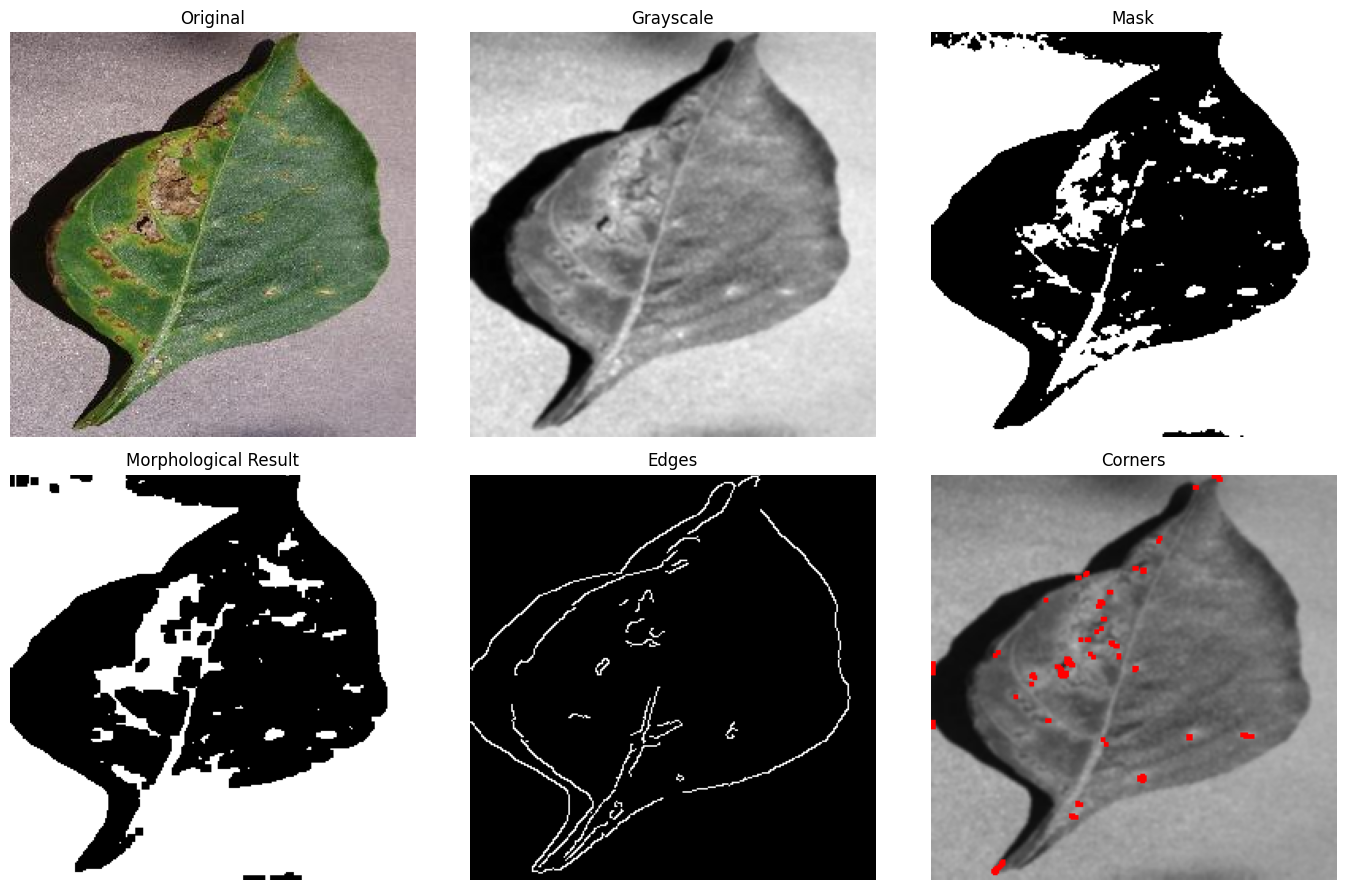

In [15]:
# Required 2x3 results grid for project reporting
figure, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(cv2.cvtColor(results["original"], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(results["grayscale"], cmap="gray")
axes[0, 1].set_title("Grayscale")
axes[0, 1].axis("off")

axes[0, 2].imshow(results["mask"], cmap="gray")
axes[0, 2].set_title("Mask")
axes[0, 2].axis("off")

axes[1, 0].imshow(results["morphology"], cmap="gray")
axes[1, 0].set_title("Morphological Result")
axes[1, 0].axis("off")

axes[1, 1].imshow(results["edges"], cmap="gray")
axes[1, 1].set_title("Edges")
axes[1, 1].axis("off")

axes[1, 2].imshow(cv2.cvtColor(results["corners"], cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("Corners")
axes[1, 2].axis("off")

figure.tight_layout()
plt.show()

In [ ]:
# Build a small experiment matrix (X, y) from dataset folders
# Folder structure expected: dataset_root/class_name/image.jpg
X = []
y = []

class_directories = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]
class_directories = [d for d in class_directories if d != "PlantVillage"]
for i, class_name in enumerate(class_directories):
    print(f"Found class {i:02d}: {class_name}")
print("")

classes_to_process = [7, 9]
for class_index in classes_to_process:
    class_name = class_directories[class_index]
    class_folder = os.path.join(dataset_root, class_name)
    image_paths = glob.glob(os.path.join(class_folder, "*.jpg"))

    for image_path in tqdm(image_paths, desc=f"Processing {class_name}"):
        pipeline_output = pipeline.run_full_extractor(image_path)
        X.append(pipeline_output["feature_vector"])
        y.append(class_name)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Dataset matrix shape:", X.shape)
print("Labels shape:", y.shape)

Found class 00: Pepper__bell___Bacterial_spot
Found class 01: Pepper__bell___healthy
Found class 02: Potato___Early_blight
Found class 03: Potato___healthy
Found class 04: Potato___Late_blight
Found class 05: Tomato_Bacterial_spot
Found class 06: Tomato_Early_blight
Found class 07: Tomato_healthy
Found class 08: Tomato_Late_blight
Found class 09: Tomato_Leaf_Mold
Found class 10: Tomato_Septoria_leaf_spot
Found class 11: Tomato_Spider_mites_Two_spotted_spider_mite
Found class 12: Tomato__Target_Spot
Found class 13: Tomato__Tomato_mosaic_virus
Found class 14: Tomato__Tomato_YellowLeaf__Curl_Virus



Processing Tomato_healthy:   0%|          | 0/1591 [00:00<?, ?it/s]

Processing Tomato_healthy:   2%|▏         | 36/1591 [00:02<01:42, 15.13it/s]

In [ ]:
# Train and evaluate baseline classifiers
evaluation_results = train_and_evaluate(X, y)

for model_name, model_metrics in evaluation_results.items():
    print(f"Model: {model_name}")
    print(f"  Accuracy: {model_metrics['accuracy']:.4f}")
    print(f"  F1-score: {model_metrics['f1_score']:.4f}")
    model_metrics['confusion_matrix_figure'].show()
    print()

In [ ]:
# Placeholder: custom descriptor and Bag of Words experiments will be added later.